# Detección de Fraude en Apertura de Cuentas

## 1) Carga y validación inicial del dataset

En este paso se comprueba que la base está en condiciones de entrar al pipeline de modelado.

### Qué se revisa
- Volumen del dataset (filas y columnas).
- Registros duplicados.
- Tasa base de fraude en la variable objetivo.
- Calidad estructural de datos: nulos, variables constantes y valores sospechosos (`-1`).

### Hallazgos clave
- El dataset tiene aproximadamente 1 millón de registros.
- No se observan duplicados.
- Existe desbalance fuerte de clase (alrededor del 1% de fraude).
- Aparecen valores `-1` que se tratarán como faltantes en el preprocesado.

### Decisión de preparación
- No eliminar registros por `-1`.
- Convertir `-1` a `NaN` y tratarlos con imputación en el pipeline.

### Conclusión
Este paso valida la calidad inicial y define criterios de limpieza para garantizar un entrenamiento consistente.

In [ ]:
# PASO 1 - Carga y validación inicial
import pandas as pd

DATA_PATH = "Dataset_base.csv"
TARGET = "fraud_bool"

# carga
df = pd.read_csv(DATA_PATH)

# resumen general
resumen = pd.Series({
    "filas": df.shape[0],
    "columnas": df.shape[1],
    "duplicados": df.duplicated().sum(),
    "tasa_fraude_%": round(df[TARGET].mean() * 100, 4)
}, name="valor")

display(resumen.to_frame())

# valores nulos
nulos = df.isna().sum()
if nulos.sum() > 0:
    display(nulos[nulos > 0].rename("n_nulos").to_frame())

# variables constantes = que tienen un solo valor 
constantes = df.nunique()
display(constantes[constantes == 1].rename("n_unique").to_frame())

# valores sospechosos (-1)
menos_uno = (df == -1).sum()
menos_uno = menos_uno[menos_uno > 0].sort_values(ascending=False)
display(menos_uno.rename("conteo_-1").to_frame())

,valor
filas,1000000.0000
columnas,32.0000
duplicados,0.0000
tasa_fraude_%,1.1029


,n_unique
device_fraud_count,1


,conteo_-1
prev_address_months_count,712920
bank_months_count,253635
current_address_months_count,4254
session_length_in_minutes,2015
credit_risk_score,488
device_distinct_emails_8w,359


### 2) Análisis exploratorio de los datos (EDA)

En este paso se realiza un análisis exploratorio para identificar patrones, entender la distribución de variables y evaluar su relación con el fraude.

### Qué se revisa
- Distribución de la variable objetivo (`fraud_bool`).
- Comportamiento de variables numéricas por clase.
- Tasa de fraude en variables categóricas.

### Hallazgos clave
- Existe desbalance severo: aproximadamente 1% fraude y 99% no fraude.
- Las variables numéricas aportan señal, pero con solapamiento entre clases.
- Las variables categóricas muestran diferencias de riesgo por categoría.

### Implicación para modelado
- La `accuracy` no es una métrica suficiente en este contexto.
- Se priorizan métricas robustas para desbalance: `Precision`, `Recall` y `PR-AUC`.
- El problema requiere modelos capaces de capturar interacciones y relaciones no lineales.

### Conclusión
El dataset contiene señal útil para detectar fraude, pero distribuida de forma compleja, por lo que se justifica el uso de modelos avanzados y evaluación orientada a negocio.

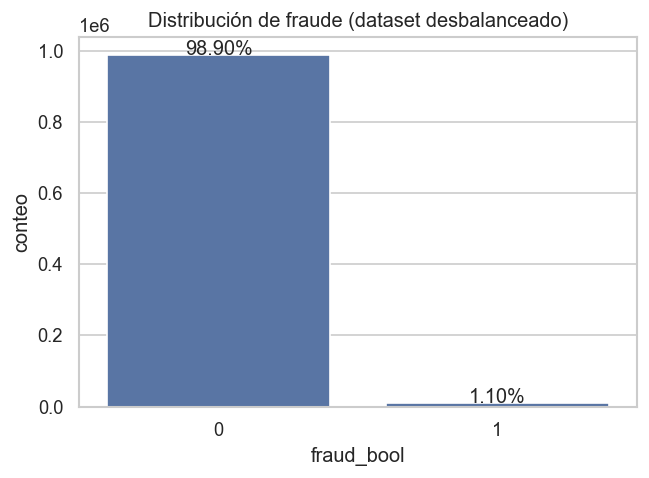

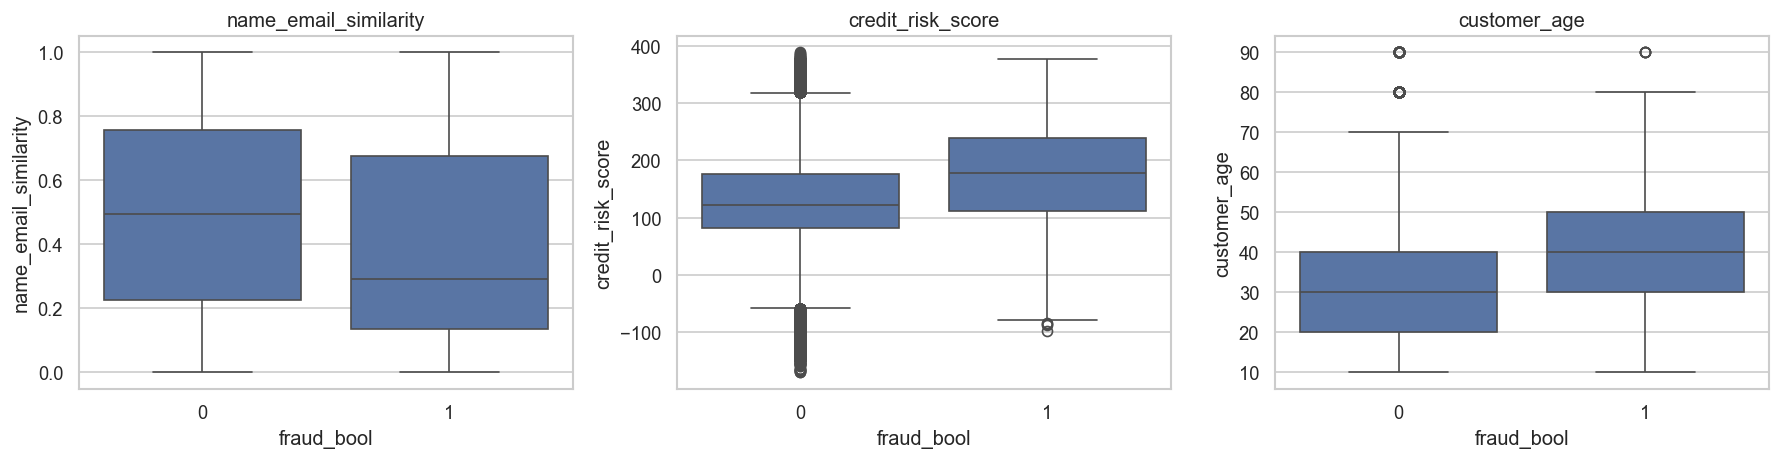

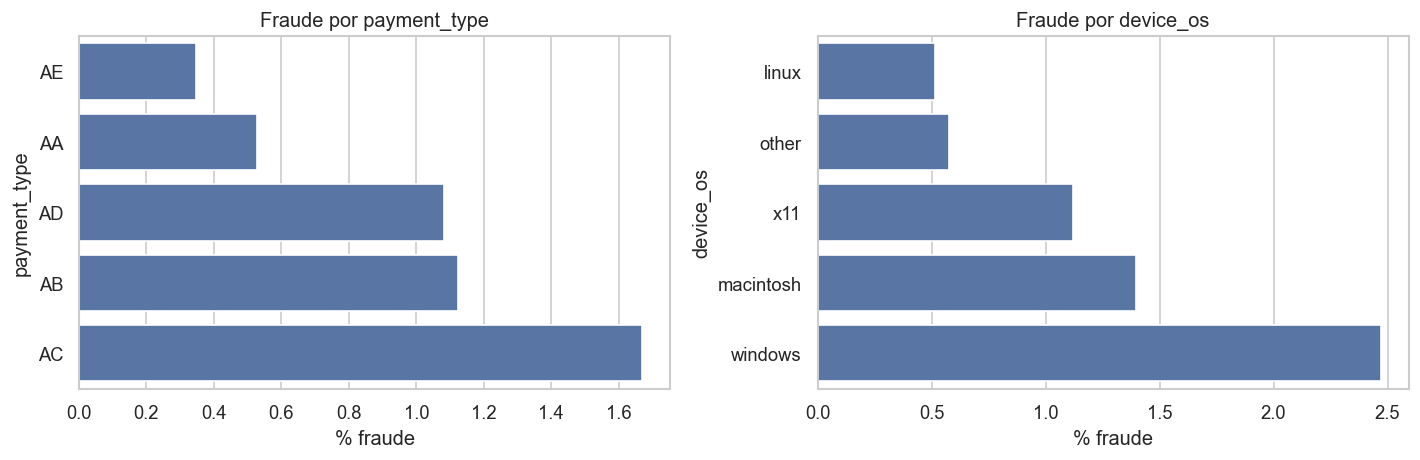

In [ ]:
# =========================
# PASO 2 - EDA = estadísticas descriptivas y visuales para entender la distribución de las variables, detectar patrones, relaciones y posibles problemas
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# =========================
# 1) DESBALANCE DE CLASES
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET, data=df)

counts = df[TARGET].value_counts().sort_index()
total = len(df)

for i, v in enumerate(counts):
    pct = (v / total) * 100
    plt.text(i, v, f"{pct:.2f}%", ha='center')

plt.title("Distribución de fraude (dataset desbalanceado)")
plt.xlabel("fraud_bool")
plt.ylabel("conteo")
plt.show()
# desbalance de clases = gráfico de barras con porcentaje


# =========================
# 2) VARIABLES NUMÉRICAS
# =========================
num_cols = [
    c for c in [
        "name_email_similarity",
        "credit_risk_score",
        "customer_age"
    ] if c in df.columns
]

if num_cols:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))

    if len(num_cols) == 1:
        axes = [axes]

    for ax_i, c in zip(axes, num_cols):
        sns.boxplot(data=df, x=TARGET, y=c, ax=ax_i)
        ax_i.set_title(c)
        ax_i.set_xlabel("fraud_bool")

    plt.tight_layout()
    plt.show()
# boxplot: resume una variable con mediana, rango central (caja) y dispersión (bigotes).
# outlier: dato muy alejado del resto; en boxplot suele verse como punto fuera de los bigotes.

# =========================
# 3) VARIABLES CATEGÓRICAS 
# =========================
cat_cols = [c for c in ["payment_type", "device_os"] if c in df.columns]

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))

    if len(cat_cols) == 1:
        axes = [axes]

    for ax_i, c in zip(axes, cat_cols):
        tmp = (
            df.groupby(c)[TARGET]
            .mean()
            .sort_values(ascending=True)
            .mul(100)
            .reset_index(name="fraud_rate")
        )

        sns.barplot(data=tmp, y=c, x="fraud_rate", ax=ax_i)
        ax_i.set_title(f"Fraude por {c}")
        ax_i.set_xlabel("% fraude")

    plt.tight_layout()
    plt.show()
# variables categóricas = porcentaje de fraude por categoría

## 3) Preparación de variables para modelado

En este paso se transforman los datos para que el entrenamiento sea consistente, reproducible y sin fuga de información.

### Qué se prepara
- Separación de variables predictoras (`X`) y objetivo (`y`).
- Limpieza inicial de valores (`-1` como faltantes) y eliminación de variables sin señal.
- Ingeniería de variables para reforzar patrones de fraude.
- División `train/test` con estratificación para conservar el desbalance real.
- Definición de preprocesado para variables numéricas y categóricas.

### Resultado esperado
- Conjuntos `X_train`, `X_test`, `y_train`, `y_test` listos para modelar.
- `preprocessor` configurado para aplicar transformaciones de forma homogénea.

### Conclusión
Este paso deja una base técnica sólida para entrenar modelos comparables y evaluar resultados de manera fiable.

In [ ]:
# =========================================
# PASO 3 - PREPARACIÓN + FEATURE ENGINEERING
# =========================================

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# =========================================
# 1) X / y
# =========================================
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# -1 → NaN
X = X.replace(-1, np.nan)

# eliminar constante
if "device_fraud_count" in X.columns:
    X = X.drop(columns=["device_fraud_count"])

# =========================================
# 2) FEATURE ENGINEERING (crear nuevas variables a partir de las existentes, basadas en intuición o patrones detectados en el EDA)
# =========================================

# flags (ejemplo: baja similitud email = sospechoso)
if "name_email_similarity" in X.columns:
    X["low_email_similarity"] = (X["name_email_similarity"] < 0.3).astype(int)

if "credit_risk_score" in X.columns:
    X["high_risk_score"] = (X["credit_risk_score"] > 0.8).astype(int)

# ratios (ejemplo: muchos emails en dispositivo pero pocos meses en el banco = sospechoso)
if "device_distinct_emails_8w" in X.columns and "bank_months_count" in X.columns:
    X["emails_per_month"] = X["device_distinct_emails_8w"] / (X["bank_months_count"] + 1)

# interacciones (ejemplo: baja similitud email + muchos emails en dispositivo = sospechoso)
if "name_email_similarity" in X.columns and "device_distinct_emails_8w" in X.columns:
    X["email_device_interaction"] = (
        X["name_email_similarity"] * X["device_distinct_emails_8w"]
    )

# missing como señal
X["missing_prev_address"] = X["prev_address_months_count"].isna().astype(int)
X["missing_bank_months"] = X["bank_months_count"].isna().astype(int)

# =========================================
# 3) TIPOS DE VARIABLES
# =========================================
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# =========================================
# 4) TRAIN / TEST
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    # test_size => 80% para entrenamiento, 20% para validación (controla capacidad de generalización)
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 5) TRANSFORMADORES
# =========================================

# numericos → imputar con mediana
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# categoricos → imputar con moda
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# =========================================
# 6) RESUMEN
# =========================================
resumen_paso3 = pd.Series({
    "features_totales": X.shape[1],
    "features_numericas": len(num_cols),
    "features_categoricas": len(cat_cols),
    "train_filas": X_train.shape[0],
    "test_filas": X_test.shape[0]
}, name="valor")

display(resumen_paso3.to_frame())

,valor
features_totales,36
features_numericas,31
features_categoricas,5
train_filas,800000
test_filas,200000


## 4) Entrenamiento de modelos (baseline y robustos)

En este paso se entrena y selecciona el modelo con mejor rendimiento para detección de fraude, utilizando el preprocesado definido en el Paso 3.

### Modelos evaluados (resumen)
- Logistic Regression (baseline): se descartó por menor capacidad para capturar patrones no lineales.
- Decision Tree: se descartó por alta varianza y tendencia a sobreajuste.
- Random Forest: mejoró estabilidad, pero con menor rendimiento global que XGBoost.
- XGBoost: modelo final seleccionado por mejor equilibrio entre detección y coste.

### Qué se ejecuta
- Configuración de parámetros de entrenamiento y costes de negocio.
- Entrenamiento del modelo principal con búsqueda de hiperparámetros.
- Optimización del umbral de decisión en validación.
- Evaluación final en test con métricas técnicas y de negocio.

### Métricas de referencia
- `PR-AUC` (principal en problemas desbalanceados).
- `ROC-AUC`.
- `Recall`, `Precision` y `F1`.
- Coste operativo (fraudes perdidos vs clientes bloqueados).

### Resultado esperado
- Modelo final entrenado en `pipelines_entrenados`.
- Umbral óptimo en `thresholds_modelos`.
- Tabla final de resultados para justificar la decisión.

### Conclusión
Este paso traduce el modelado en una decisión operativa medible y alineada con el impacto de negocio.

### Paso 4.1 (resumen)
- Configura `MAX_TRAIN`, `COSTE_FN`, `COSTE_FP` y `N_ITER`.
- Define reglas de ejecución antes de entrenar.

In [ ]:
# =========================================
# PASO 4.1 - CONFIGURACION
# =========================================

MAX_TRAIN = 1000000   # cambiar aquí sin tocar nada más

# coste de negocio (clave)
# fn = cuanto mayor es el numero, más penaliza el modelo los falsos negativos (fraudes no detectados)
COSTE_FN = 10
# fp = cuanto mayor es el numero, más penaliza el modelo los falsos positivos (clientes legítimos bloqueados)
COSTE_FP = 1

# iter = número de combinaciones a probar en Random Search
N_ITER = 15

print("Configuración cargada")

Configuración cargada


### Paso 4.2 (entrenamiento del modelo)

En este bloque se entrena el modelo final (`XGBoost`) dentro de un pipeline completo, combinando preprocesado, ajuste por desbalance y búsqueda de hiperparámetros.

#### Qué se hace en este paso
- Se verifica que existan las variables clave (`X_train`, `X_test`, `y_train`, `y_test`); si faltan, se reconstruyen desde `df` para mantener robustez de ejecución.
- Se controla el coste de cómputo con `MAX_TRAIN`, limitando el volumen de datos si el conjunto es muy grande.
- Se crea una partición interna `train/val` para ajustar hiperparámetros sin usar el test final.
- Se define un preprocesado por tipo de variable:
  - numéricas: imputación por mediana,
  - categóricas: imputación por moda + `TargetEncoder`.
- Se calcula el desbalance real de clases y se incorpora en `XGBoost` con `scale_pos_weight`.
- Se ejecuta `RandomizedSearchCV` con una búsqueda sobre parámetros de complejidad, regularización y aprendizaje.

#### Por qué es importante
- Evita entrenamientos frágiles por ejecución fuera de orden.
- Reduce riesgo de sobreajuste al separar entrenamiento y validación interna.
- Mejora sensibilidad a fraude al tratar explícitamente el desbalance.
- Permite encontrar una configuración más sólida que un modelo con parámetros por defecto.

#### Resultado esperado
- `best_model`: mejor pipeline encontrado en la búsqueda.
- `pipelines_entrenados`: diccionario con el modelo final (`XGBoost`) listo para evaluación en el Paso 4.3.
- Base preparada para optimizar umbral y medir impacto de negocio.

In [ ]:
# =========================================
# PASO 4.2 - ENTRENAMIENTO 
# =========================================

import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import loguniform, randint
from xgboost import XGBClassifier
from category_encoders import TargetEncoder

# =========================================
# RECONSTRUCCIÓN (si falta paso 3)
# =========================================
required_vars = ["X_train", "X_test", "y_train", "y_test"]

if not all(var in globals() for var in required_vars):

    if "df" not in globals():
        raise ValueError("Falta df. Ejecuta antes la carga de datos.")

    if "TARGET" not in globals():
        TARGET = "fraud_bool"

    X = df.drop(columns=[TARGET]).copy()
    y = df[TARGET].astype(int).copy()

    # limpieza
    X = X.replace(-1, np.nan)

    if "device_fraud_count" in X.columns:
        X = X.drop(columns=["device_fraud_count"])

    # tipos
    cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

# =========================================
# SAMPLE (control tiempo)
# =========================================
if X_train.shape[0] > MAX_TRAIN:
    X_train_fit = X_train.sample(n=MAX_TRAIN, random_state=42)
    y_train_fit = y_train.loc[X_train_fit.index]
else:
    X_train_fit = X_train
    y_train_fit = y_train

# =========================================
# SPLIT TRAIN / VAL
# =========================================
X_train_real, X_val, y_train_real, y_val = train_test_split(
    X_train_fit, y_train_fit,
    test_size=0.2,
    stratify=y_train_fit,
    random_state=42
)

# =========================================
# PREPROCESSOR 
# =========================================
cat_cols = X_train_real.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X_train_real.columns if c not in cat_cols]

# numeros -> imputar con mediana
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# categoricos -> imputar con moda + target encoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_enc", TargetEncoder(smoothing=0.3))  # evita overfitting
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

ratio = int((y_train_real == 0).sum() / (y_train_real == 1).sum())

# =========================================
# MODELO XGBOOST
# =========================================

# xgboost elegido por su potencia y capacidad de manejar desbalance (con scale_pos_weight)
# y porque no requiere escalado (importante para evitar data leakage en pipelines)
xgb = XGBClassifier(
    # metricas de evaluación (logloss = probabilidad, no solo clase)
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=ratio
)

# =========================================
# HIPERPARÁMETROS
# =========================================
# se implementaron rangos amplios para explorar bien el espacio
param_dist = {
    
    # n_estimators = cantidad de árboles a entrenar
    "model__n_estimators": randint(300, 700),
    # max_depth = profundidad del árbol (controla complejidad)
    "model__max_depth": randint(3, 6),
    # learning_rate = cuánto se ajustan los árboles a cada iteración
    "model__learning_rate": loguniform(0.02, 0.1),
    # subsample = % filas usadas por cada árbol (controla overfitting)
    "model__subsample": [0.6, 0.8, 1.0],
    # colsample_bytree = % columnas usadas por cada árbol (controla overfitting)
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    # min_child_weight = mínimo número de muestras en hojas (controla complejidad)
    "model__min_child_weight": randint(8, 15),
    # gamma = mínimo que debe mejorar la función objetivo para hacer un split (controla complejidad)
    "model__gamma": loguniform(0.1, 2),
    # reg_alpha = regularización L1 (controla overfitting) L1 = Lasso (elimina features)
    "model__reg_alpha": loguniform(1e-3, 1),
    # reg_lambda = regularización L2 (controla overfitting) L2 = Ridge (reduce peso de features)
    "model__reg_lambda": loguniform(1e-3, 5),
}

# =========================================
# PIPELINE
# =========================================
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

# =========================================
# RANDOM SEARCH
# =========================================
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="average_precision",
    # cv: valor = número de folds para validación cruzada (controla estabilidad de resultados)
    cv=2,
    n_jobs=-1,
    random_state=42,
    # verbose: valor = nivel de detalle en salida (0=silencioso, 1=progreso básico, 2=detallado)
    verbose=1
)

# =========================================
# ENTRENAMIENTO
# =========================================
print("\nEntrenando XGBoost...")

search.fit(X_train_real, y_train_real)

best_model = search.best_estimator_

pipelines_entrenados = {
    "XGBoost": best_model
}

print("\nXGBoost listo")
print("\nEntrenamiento completado")


🔍 Entrenando XGBoost...
Fitting 2 folds for each of 15 candidates, totalling 30 fits

✔ XGBoost listo

🔥 Entrenamiento completado


### Paso 4.3 (optimización de umbral y evaluación)

En este bloque se convierte la probabilidad del modelo en una decisión operativa, seleccionando el threshold que mejor equilibra rendimiento técnico e impacto de negocio.

#### Qué se hace en este paso
- Se define un rango de thresholds y se evalúa cada valor sobre validación.
- Para cada threshold, se calculan `recall`, `precision` y coste (`FN * COSTE_FN + FP * COSTE_FP`).
- Se aplican filtros mínimos de calidad (`MIN_RECALL` y `MIN_PRECISION`) para descartar opciones no viables.
- Entre las opciones válidas, se prioriza mayor precisión y, en empate, menor coste.
- El threshold óptimo se guarda en `thresholds_modelos`.

#### Evaluación final en test
- Se aplica el threshold elegido sobre `X_test`.
- Se calculan métricas técnicas: `PR-AUC`, `ROC-AUC`, `Recall`, `Precision`, `F1`.
- Se calculan métricas de negocio: fraudes detectados, fraudes perdidos, clientes bloqueados y coste total.
- Se añade control de sobreajuste comparando `train_auc` vs `test_auc` (`gap`).

#### Por qué es importante
- Un buen modelo probabilístico no es suficiente sin un umbral adecuado.
- Este paso alinea la decisión del modelo con las prioridades reales del negocio.
- Permite justificar de forma cuantitativa el compromiso entre detectar más fraude y reducir bloqueos innecesarios.

#### Resultado esperado
- `thresholds_modelos`: umbral óptimo por modelo.
- `resultados_df`: tabla final con métricas técnicas, métricas de negocio y señal de overfitting, lista para decisión.

In [ ]:
# =========================
# PASO 4.3 - THRESHOLD
# =========================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

resultados = []
thresholds_modelos = {}

# rango de thresholds a evaluar (puedo ajustar)
thresholds = np.linspace(0.05, 0.8, 200)

# filtros mínimos ( + recall = + fraudes detectados,
#                   + precision = - clientes molestos)
MIN_RECALL = 0.5
MIN_PRECISION = 0.1

for nombre, pipe in pipelines_entrenados.items():

    print(f"\nEvaluando modelo: {nombre}")

    proba_val = pipe.predict_proba(X_val)[:, 1]

    # inicialización con un valor razonable (puedo ajustar)
    best_threshold = 0.3
    best_precision = 0
    best_recall = 0
    best_coste = np.inf

    # =========================
    # BÚSQUEDA DE THRESHOLD
    # =========================
    for t in thresholds:

        pred_val = (proba_val >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, pred_val).ravel()

        # métricas intermedias
        recall_tmp = tp / (tp + fn + 1e-6)
        precision_tmp = tp / (tp + fp + 1e-6)
        coste_tmp = fn * COSTE_FN + fp * COSTE_FP

        # filtros mínimos
        if recall_tmp < MIN_RECALL:
            continue
        # si no llega a la precision mínima, tampoco sirve
        if precision_tmp < MIN_PRECISION:
            continue
        
        # criterio principal -> maximizar precision
        if precision_tmp > best_precision:
            best_precision = precision_tmp
            best_recall = recall_tmp
            best_threshold = t
            best_coste = coste_tmp

        # si la precision es igual, elige el que menor coste tenga
        elif precision_tmp == best_precision and coste_tmp < best_coste:
            best_threshold = t
            best_coste = coste_tmp
            best_recall = recall_tmp
    
    thresholds_modelos[nombre] = best_threshold

    print(f"→ Threshold: {best_threshold:.3f}")
    print(f"→ Recall: {best_recall:.3f} | Precision: {best_precision:.3f}")

    # =========================
    # TEST → evaluación real
    # =========================
    proba_test = pipe.predict_proba(X_test)[:, 1]
    pred_test = (proba_test >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()

    coste_test = fn * COSTE_FN + fp * COSTE_FP

    # =========================
    # OVERFITTING
    # =========================
    train_proba = pipe.predict_proba(X_train_real)[:, 1]
    
    train_auc = roc_auc_score(y_train_real, train_proba)
    test_auc = roc_auc_score(y_test, proba_test)

    gap = train_auc - test_auc

    # =========================
    # MÉTRICAS
    # =========================
    
    # recall = tp / (tp + fn) → si no hay positivos reales, recall es 0
    recall = recall_score(y_test, pred_test)
    # precision = tp / (tp + fp) → si no hay positivos predichos, precision es 0 
    precision = precision_score(y_test, pred_test, zero_division=0)
    # f1 = media armónica entre recall y precision (útil para comparar modelos)
    f1 = f1_score(y_test, pred_test, zero_division=0)
    # pr auc = área bajo la curva de precisión-recall (más útil en desbalance)
    pr_auc = average_precision_score(y_test, proba_test)
    # recall_precision_cond = recall solo si precision > 0.2, sino 0 (útil para negocio)
    recall_precision_cond = recall if precision > 0.2 else 0

    # =========================
    # RESULTADOS
    # =========================
    resultados.append({
        "modelo": nombre,

        "threshold": round(best_threshold, 4),

        "pr_auc": pr_auc,
        "roc_auc": test_auc,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "recall@precision>0.2": recall_precision_cond,

        # negocio
        "coste_val": int(best_coste),
        "coste_test": int(coste_test),
        "fraudes_detectados": int(tp),
        "fraudes_perdidos": int(fn),
        "clientes_bloqueados": int(fp),

        # overfitting
        "train_auc": train_auc,
        "gap": gap
    })

# =========================
# RESULTADOS FINALES
# =========================
resultados_df = pd.DataFrame(resultados)

#orden más útil ahora → por precision (o recall si prefieres)
resultados_df = resultados_df.sort_values("precision", ascending=False)

display(resultados_df.round(4))


Evaluando modelo: XGBoost
→ Threshold: 0.800
→ Recall: 0.525 | Precision: 0.116


,modelo,threshold,pr_auc,roc_auc,recall,precision,f1,recall@precision>0.2,coste_val,coste_test,fraudes_detectados,fraudes_perdidos,clientes_bloqueados,train_auc,gap
0,XGBoost,0.8,0.18,0.8987,0.5363,0.1192,0.1951,0,15464,18968,1183,1023,8738,0.9197,0.021


### Paso 4.4 (visualización y comunicación de resultados)

En este bloque se transforma la evaluación numérica en evidencia visual para comparar modelos y explicar decisiones de forma clara.

#### Qué se muestra
- Matrices de confusión por modelo con su threshold óptimo.
- Curvas ROC para comparar capacidad de discriminación global.
- Curvas Precision-Recall, clave en escenarios con fuerte desbalance.

#### Cómo se interpreta
- Matriz de confusión: permite ver el balance real entre fraudes detectados (`TP`) y bloqueos erróneos (`FP`).
- ROC-AUC: mide separación general entre clases; útil como referencia global.
- PR-AUC: prioritaria en fraude, porque refleja mejor el rendimiento cuando la clase positiva es minoritaria.
- Baseline en Precision-Recall: ayuda a validar si el modelo aporta valor real frente a una referencia simple.

#### Por qué es importante
- Facilita comparar modelos sin depender solo de una tabla de métricas.
- Hace visible el compromiso entre detección de fraude y fricción a clientes legítimos.
- Permite comunicar resultados técnicos a negocio con una narrativa clara y defendible.

#### Resultado esperado
- Gráficas listas para presentación y toma de decisión.
- Soporte visual para justificar el modelo y el umbral elegidos en el Paso 4.3.

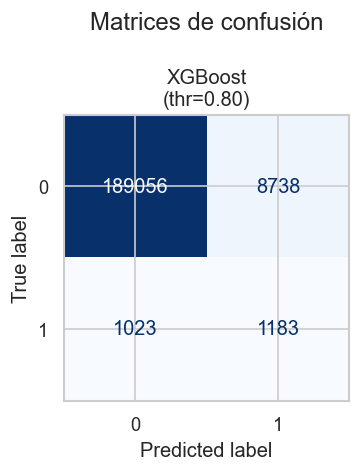

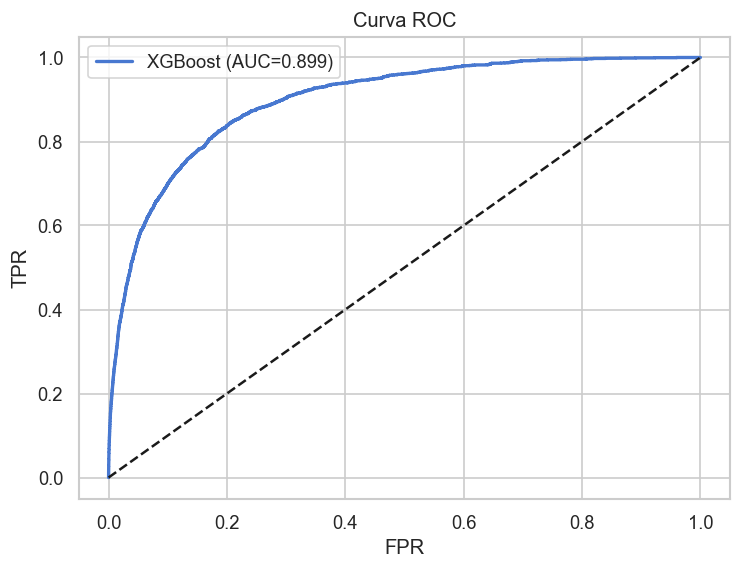

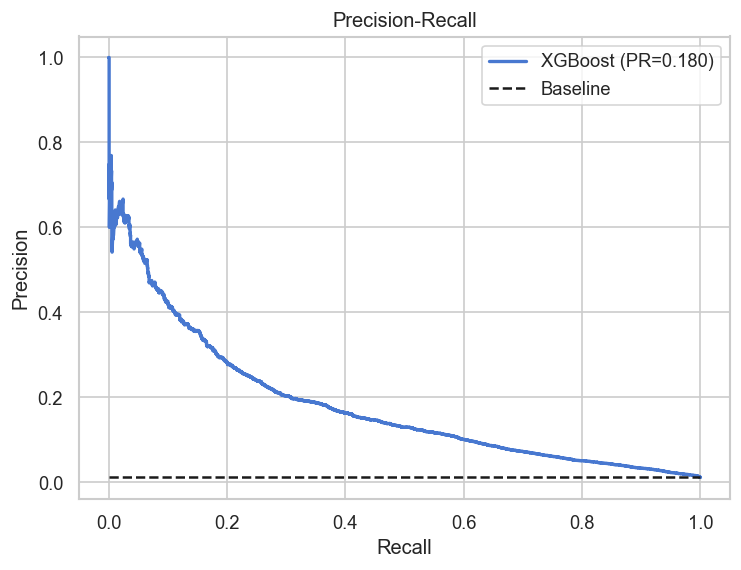

In [ ]:
# =========================
# PASO 4.4 - VISUALIZACIÓN 
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# =========================
# 1) MATRICES DE CONFUSIÓN
# =========================
fig, axes = plt.subplots(1, len(pipelines_entrenados), figsize=(16,4))

if len(pipelines_entrenados) == 1:
    axes = [axes]

for ax, (nombre, pipe) in zip(axes, pipelines_entrenados.items()):
    proba = pipe.predict_proba(X_test)[:, 1]
    thr = thresholds_modelos[nombre]
    pred = (proba >= thr).astype(int)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")

    ax.set_title(f"{nombre}\n(thr={thr:.2f})")

plt.suptitle("Matrices de confusión")
plt.tight_layout()
plt.show()
# matriz de confusión: [[TN, FP], 
#                       [FN, TP]]
#                      ----------
#                      [[clientes buenos permitidos (TN), clientes buenos bloqueados (FP)],
#                       [fraudes no detectados (FN), fraudes detectados (TP)]]

# =========================
# 2) CURVA ROC
# =========================
plt.figure(figsize=(7,5))

for nombre, pipe in pipelines_entrenados.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)

    plt.plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()
# curva roz: cuanto más cerca de la esquina superior izquierda, mejor
# (más TPR y menos FPR = más fraudes detectados y menos clientes buenos bloqueados)
# auc = mejor modelo tiene un auc más cercano a 1 (0.5 = modelo aleatorio)

# =========================
# 3) PRECISION-RECALL
# =========================
plt.figure(figsize=(7,5))

for nombre, pipe in pipelines_entrenados.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)

    plt.plot(recall, precision, linewidth=2, label=f"{nombre} (PR={pr_auc:.3f})")

baseline = y_test.mean()
plt.hlines(y=baseline, xmin=0, xmax=1, colors="k", linestyles="--", label="Baseline")

plt.title("Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()
# curva precision-recall: cuanto más cerca de la esquina superior derecha, mejor
# precision = + fraudes detectados / + clientes bloqueados
# recall = + fraudes detectados / + fraudes totales
# pr_auc 0.18 = el modelo es 18% mejor que un modelo aleatorio (baseline)
